PYTORCH INFORMATION
PyTorch Version: 2.11.0+cpu
Device: CPU

DATASET INFORMATION
Training samples   : 50000
Validation samples : 10000
Test samples       : 10000


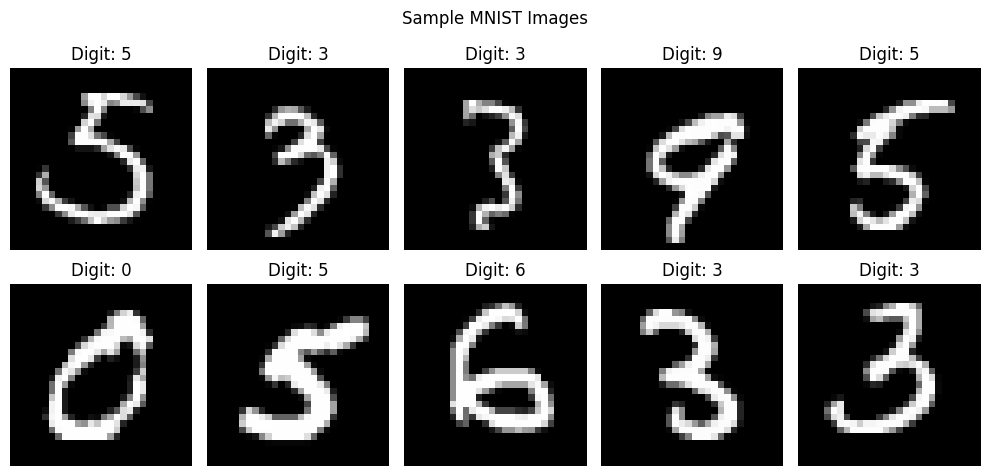



EXPERIMENT A: BASELINE - NO REGULARIZATION

Starting Training...
----------------------------------------------------------------------
Epoch [01/10] | Train Loss: 0.3482 | Train Acc: 90.04% | Val Loss: 0.1950 | Val Acc: 94.20%
Epoch [02/10] | Train Loss: 0.1508 | Train Acc: 95.44% | Val Loss: 0.1389 | Val Acc: 95.75%
Epoch [03/10] | Train Loss: 0.1054 | Train Acc: 96.73% | Val Loss: 0.1156 | Val Acc: 96.50%
Epoch [04/10] | Train Loss: 0.0796 | Train Acc: 97.51% | Val Loss: 0.1247 | Val Acc: 96.21%
Epoch [05/10] | Train Loss: 0.0625 | Train Acc: 98.01% | Val Loss: 0.1061 | Val Acc: 96.67%
Epoch [06/10] | Train Loss: 0.0512 | Train Acc: 98.32% | Val Loss: 0.0954 | Val Acc: 97.18%
Epoch [07/10] | Train Loss: 0.0399 | Train Acc: 98.74% | Val Loss: 0.1016 | Val Acc: 97.29%
Epoch [08/10] | Train Loss: 0.0329 | Train Acc: 98.96% | Val Loss: 0.0911 | Val Acc: 97.56%
Epoch [09/10] | Train Loss: 0.0280 | Train Acc: 99.12% | Val Loss: 0.0943 | Val Acc: 97.42%
Epoch [10/10] | Train Loss: 0.0229

In [ ]:
# ============================================================
# ANN & DEEP LEARNING
# LAB 05: MLP ON MNIST USING PYTORCH
# ============================================================
#
# Objective:
# Build and train a Multilayer Perceptron (MLP) on the MNIST
# handwritten digit dataset and compare four configurations:
#
#   A. Baseline       -> No regularization
#   B. L2             -> Weight Decay
#   C. Dropout        -> Dropout p = 0.3
#   D. BatchNorm      -> Batch Normalization
#
# We will:
#   1. Load MNIST
#   2. Preprocess the images
#   3. Build four MLP models
#   4. Train each model
#   5. Record training and validation accuracy
#   6. Plot learning curves
#   7. Compare final results
#   8. Test the models on unseen MNIST test data
#
# Framework:
#   PyTorch
#
# Dataset:
#   MNIST
#
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 2. CHECK PYTORCH VERSION AND DEVICE
# ============================================================

print("=" * 60)
print("PYTORCH INFORMATION")
print("=" * 60)

print("PyTorch Version:", torch.__version__)

# Check whether GPU is available.
# If Google Colab GPU is enabled, the model will use CUDA.
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Device: GPU (CUDA)")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Device: CPU")


# ============================================================
# 3. LOAD AND PREPROCESS MNIST
# ============================================================

# MNIST images are 28 x 28 grayscale images.
#
# ToTensor():
#     Converts an image into a PyTorch tensor.
#
# Normalize():
#     Normalizes the pixel values.
#
# Mean and standard deviation below are commonly used for MNIST.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


# Download training dataset
train_full_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# Download test dataset
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# ============================================================
# 4. DIVIDE TRAINING DATA INTO TRAINING AND VALIDATION SETS
# ============================================================

# Original MNIST training dataset:
#     60,000 images
#
# We divide it into:
#     50,000 -> Training
#     10,000 -> Validation
#
# The validation data is used to evaluate the model during
# training without updating the model's weights.

train_size = 50000
val_size = 10000

train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size]
)


print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Training samples   :", len(train_dataset))
print("Validation samples :", len(val_dataset))
print("Test samples       :", len(test_dataset))


# ============================================================
# 5. CREATE DATALOADERS
# ============================================================

# DataLoader divides the dataset into batches.
#
# batch_size = 128 means that approximately 128 images are
# processed together before the optimizer updates the weights.

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# ============================================================
# 6. DISPLAY SOME MNIST IMAGES
# ============================================================

# Get one batch of images and labels.

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    # squeeze() removes the channel dimension.
    # MNIST image shape is:
    #     [1, 28, 28]
    #
    # After squeeze():
    #     [28, 28]

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title("Digit: " + str(labels[i].item()))

    plt.axis("off")

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()


# ============================================================
# 7. UNDERSTANDING THE INPUT SIZE
# ============================================================

# Each MNIST image has:
#
#     28 x 28 = 784 pixels
#
# The MLP expects a vector rather than a 2D image.
#
# Therefore:
#
#     28 x 28 image
#          ↓
#       Flatten
#          ↓
#      784 values
#
# The Flatten layer will perform this conversion automatically.

input_size = 784
hidden_size_1 = 128
hidden_size_2 = 64
output_size = 10


# ============================================================
# 8. BASELINE MODEL
# ============================================================
#
# Architecture:
#
#       784
#        |
#      Linear
#        |
#       128
#        |
#      ReLU
#        |
#       64
#        |
#      ReLU
#        |
#       10
#
# This model has:
#
#     No Dropout
#     No L2 regularization
#     No Batch Normalization
#
# It will be our BASELINE for comparison.


class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # Convert 28 x 28 image into 784 values
            nn.Flatten(),

            # First fully connected layer
            nn.Linear(784, 128),

            # Non-linear activation function
            nn.ReLU(),

            # Second fully connected layer
            nn.Linear(128, 64),

            # Non-linear activation function
            nn.ReLU(),

            # Output layer
            # 10 neurons = digits 0 through 9
            nn.Linear(64, 10)
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 9. DROPOUT MODEL
# ============================================================
#
# Dropout randomly disables some neurons during training.
#
# p = 0.3 means approximately 30% of the activations are
# randomly dropped during training.
#
# Dropout is a regularization technique that can help reduce
# overfitting.


class MLP_Dropout(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # Flatten:
            # 28 x 28 -> 784
            nn.Flatten(),

            # First hidden layer
            nn.Linear(784, 128),

            # Activation
            nn.ReLU(),

            # Drop 30% of activations during training
            nn.Dropout(p=0.3),

            # Second hidden layer
            nn.Linear(128, 64),

            # Activation
            nn.ReLU(),

            # Dropout again
            nn.Dropout(p=0.3),

            # Output layer
            nn.Linear(64, 10)
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 10. BATCH NORMALIZATION MODEL
# ============================================================
#
# Batch Normalization normalizes the activations of a layer
# using statistics from the current mini-batch during training.
#
# Here:
#
#     Linear -> BatchNorm -> ReLU
#
# is used for each hidden layer.


class MLP_BatchNorm(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            # Flatten:
            # 28 x 28 -> 784
            nn.Flatten(),

            # First hidden layer
            nn.Linear(784, 128),

            # Batch normalization for 128 features
            nn.BatchNorm1d(128),

            # Activation
            nn.ReLU(),

            # Second hidden layer
            nn.Linear(128, 64),

            # Batch normalization for 64 features
            nn.BatchNorm1d(64),

            # Activation
            nn.ReLU(),

            # Output layer
            nn.Linear(64, 10)
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 11. LOSS FUNCTION
# ============================================================

# MNIST is a multi-class classification problem.
#
# There are 10 possible classes:
#
#     0, 1, 2, 3, 4, 5, 6, 7, 8, 9
#
# CrossEntropyLoss is commonly used for multi-class
# classification.
#
# IMPORTANT:
# We do NOT add Softmax to the final layer.
# CrossEntropyLoss internally handles the required operation.

criterion = nn.CrossEntropyLoss()


# ============================================================
# 12. TRAINING FUNCTION
# ============================================================
#
# This function performs one complete training epoch.
#
# Steps:
#
#     1. Get a batch
#     2. Move data to CPU/GPU
#     3. Clear old gradients
#     4. Forward propagation
#     5. Calculate loss
#     6. Backpropagation
#     7. Update weights
#     8. Calculate accuracy


def train_one_epoch(model, loader, criterion, optimizer):

    # Put model into training mode.
    #
    # This is particularly important for models containing
    # Dropout and Batch Normalization.

    model.train()

    correct = 0
    total = 0
    running_loss = 0.0

    for images, labels in loader:

        # Move images and labels to selected device.
        images = images.to(device)
        labels = labels.to(device)

        # ----------------------------------------------------
        # STEP 1: CLEAR OLD GRADIENTS
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # STEP 2: FORWARD PROPAGATION
        # ----------------------------------------------------

        outputs = model(images)

        # ----------------------------------------------------
        # STEP 3: CALCULATE LOSS
        # ----------------------------------------------------

        loss = criterion(outputs, labels)

        # ----------------------------------------------------
        # STEP 4: BACKPROPAGATION
        # ----------------------------------------------------
        #
        # PyTorch automatically calculates gradients.

        loss.backward()

        # ----------------------------------------------------
        # STEP 5: UPDATE WEIGHTS
        # ----------------------------------------------------

        optimizer.step()

        # ----------------------------------------------------
        # CALCULATE STATISTICS
        # ----------------------------------------------------

        running_loss += loss.item() * images.size(0)

        # Find the class with the highest output value.
        #
        # dim=1 means we select the highest value across
        # the 10 output neurons.

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    # Average loss for the epoch

    epoch_loss = running_loss / total

    # Accuracy

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy


# ============================================================
# 13. VALIDATION FUNCTION
# ============================================================
#
# During validation:
#
#     - We do NOT update weights.
#     - We do NOT calculate gradients.
#
# Therefore we use:
#
#     model.eval()
#     torch.no_grad()


def evaluate(model, loader, criterion):

    # Put model into evaluation mode.
    #
    # This changes the behavior of Dropout and BatchNorm.

    model.eval()

    correct = 0
    total = 0
    running_loss = 0.0

    # Disable gradient calculation.
    # This saves memory and computation.

    with torch.no_grad():

        for images, labels in loader:

            # Move data to device.

            images = images.to(device)
            labels = labels.to(device)

            # Forward propagation

            outputs = model(images)

            # Calculate loss

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # Get predicted class

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    # Average validation loss

    epoch_loss = running_loss / total

    # Validation accuracy

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy


# ============================================================
# 14. COMPLETE MODEL TRAINING FUNCTION
# ============================================================
#
# This function trains a model for multiple epochs.
#
# It stores:
#
#     Training Loss
#     Training Accuracy
#     Validation Loss
#     Validation Accuracy
#
# These values will later be used to create learning curves.


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=10
):

    # Dictionary for storing training history.

    history = {

        "train_loss": [],
        "train_acc": [],

        "val_loss": [],
        "val_acc": []
    }

    print("\nStarting Training...")
    print("-" * 70)

    for epoch in range(epochs):

        # ----------------------------------------------------
        # TRAINING
        # ----------------------------------------------------

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion
        )

        # ----------------------------------------------------
        # SAVE RESULTS
        # ----------------------------------------------------

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # ----------------------------------------------------
        # DISPLAY RESULTS
        # ----------------------------------------------------

        print(
            f"Epoch [{epoch + 1:02d}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

    print("-" * 70)

    return history


# ============================================================
# 15. NUMBER OF EPOCHS
# ============================================================

# Students can increase this value after the first experiment.
#
# 10 epochs is enough for this laboratory exercise.

epochs = 10


# ============================================================
# EXPERIMENT A
# BASELINE - NO REGULARIZATION
# ============================================================

print("\n")
print("=" * 70)
print("EXPERIMENT A: BASELINE - NO REGULARIZATION")
print("=" * 70)

# Create a new model

model_baseline = MLP().to(device)

# Adam optimizer
#
# weight_decay is NOT used here.

optimizer_baseline = optim.Adam(
    model_baseline.parameters(),
    lr=0.001
)

# Train

history_baseline = train_model(
    model_baseline,
    train_loader,
    val_loader,
    criterion,
    optimizer_baseline,
    epochs
)


# ============================================================
# EXPERIMENT B
# L2 REGULARIZATION / WEIGHT DECAY
# ============================================================

print("\n")
print("=" * 70)
print("EXPERIMENT B: L2 REGULARIZATION")
print("=" * 70)

# Create a fresh model.
#
# We create a new model so that this experiment starts
# with different/random initial weights rather than using
# the already trained baseline model.

model_l2 = MLP().to(device)

# weight_decay applies L2-style regularization.
#
# Conceptually:
#
# Total Loss =
#     Classification Loss + λ * Sum(weights²)
#
# The optimizer discourages excessively large weights.

optimizer_l2 = optim.Adam(
    model_l2.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

# Train

history_l2 = train_model(
    model_l2,
    train_loader,
    val_loader,
    criterion,
    optimizer_l2,
    epochs
)


# ============================================================
# EXPERIMENT C
# DROPOUT p = 0.3
# ============================================================

print("\n")
print("=" * 70)
print("EXPERIMENT C: DROPOUT (p = 0.3)")
print("=" * 70)

# Create Dropout model

model_dropout = MLP_Dropout().to(device)

# Adam optimizer

optimizer_dropout = optim.Adam(
    model_dropout.parameters(),
    lr=0.001
)

# Train

history_dropout = train_model(
    model_dropout,
    train_loader,
    val_loader,
    criterion,
    optimizer_dropout,
    epochs
)


# ============================================================
# EXPERIMENT D
# BATCH NORMALIZATION
# ============================================================

print("\n")
print("=" * 70)
print("EXPERIMENT D: BATCH NORMALIZATION")
print("=" * 70)

# Create Batch Normalization model

model_batchnorm = MLP_BatchNorm().to(device)

# Adam optimizer

optimizer_batchnorm = optim.Adam(
    model_batchnorm.parameters(),
    lr=0.001
)

# Train

history_batchnorm = train_model(
    model_batchnorm,
    train_loader,
    val_loader,
    criterion,
    optimizer_batchnorm,
    epochs
)


# ============================================================
# 16. STORE ALL EXPERIMENT RESULTS
# ============================================================

results = {

    "Baseline": history_baseline,

    "L2": history_l2,

    "Dropout": history_dropout,

    "BatchNorm": history_batchnorm
}


# ============================================================
# 17. DISPLAY FINAL TRAINING AND VALIDATION ACCURACY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL ACCURACY COMPARISON")
print("=" * 70)

print(
    f"{'Configuration':<15}"
    f"{'Train Accuracy':<20}"
    f"{'Validation Accuracy':<20}"
)

print("-" * 55)

for name, history in results.items():

    final_train_accuracy = history["train_acc"][-1]

    final_validation_accuracy = history["val_acc"][-1]

    print(
        f"{name:<15}"
        f"{final_train_accuracy:<20.2f}"
        f"{final_validation_accuracy:<20.2f}"
    )


# ============================================================
# 18. PLOT TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

for name, history in results.items():

    plt.plot(
        range(1, epochs + 1),
        history["train_acc"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 19. PLOT VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

for name, history in results.items():

    plt.plot(
        range(1, epochs + 1),
        history["val_acc"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 20. PLOT TRAINING LOSS
# ============================================================

plt.figure(figsize=(10, 6))

for name, history in results.items():

    plt.plot(
        range(1, epochs + 1),
        history["train_loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 21. PLOT VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))

for name, history in results.items():

    plt.plot(
        range(1, epochs + 1),
        history["val_loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 22. TEST ALL FOUR MODELS
# ============================================================
#
# The test dataset was not used for training or validation.
#
# It gives us a final measure of performance on unseen data.


print("\n")
print("=" * 70)
print("FINAL TEST ACCURACY")
print("=" * 70)

test_results = {}

for name, model in [

    ("Baseline", model_baseline),

    ("L2", model_l2),

    ("Dropout", model_dropout),

    ("BatchNorm", model_batchnorm)

]:

    test_loss, test_accuracy = evaluate(
        model,
        test_loader,
        criterion
    )

    test_results[name] = test_accuracy

    print(
        f"{name:<15} "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Accuracy: {test_accuracy:.2f}%"
    )


# ============================================================
# 23. FINAL COMPARISON TABLE
# ============================================================

print("\n")
print("=" * 85)
print("COMPLETE EXPERIMENT COMPARISON")
print("=" * 85)

print(
    f"{'Configuration':<15}"
    f"{'Train Acc.':<15}"
    f"{'Validation Acc.':<20}"
    f"{'Test Acc.':<15}"
)

print("-" * 65)

for name, history in results.items():

    train_acc = history["train_acc"][-1]

    val_acc = history["val_acc"][-1]

    test_acc = test_results[name]

    print(
        f"{name:<15}"
        f"{train_acc:<15.2f}"
        f"{val_acc:<20.2f}"
        f"{test_acc:<15.2f}"
    )


# ============================================================
# 24. DISPLAY SOME FINAL PREDICTIONS
# ============================================================
#
# We will use the Batch Normalization model for demonstration.
#
# Students can replace it with any of the other models.


selected_model = model_batchnorm

selected_model.eval()

# Get one batch from test data

images, labels = next(iter(test_loader))

images_device = images.to(device)

# Disable gradients because we are only making predictions

with torch.no_grad():

    outputs = selected_model(images_device)

    # Select the output neuron with the highest value.
    # This becomes our predicted digit.

    _, predictions = torch.max(outputs, 1)


# Display first 10 predictions

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    actual = labels[i].item()

    predicted = predictions[i].item()

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.suptitle("MNIST Predictions - Batch Normalization Model")

plt.tight_layout()

plt.show()


# ============================================================
# 25. FINAL LAB SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("LAB 04 COMPLETED")
print("=" * 70)

print("""
Students have implemented and compared:

1. Baseline MLP
   -> No regularization

2. L2 Regularization
   -> Weight decay

3. Dropout
   -> Dropout p = 0.3

4. Batch Normalization
   -> BatchNorm1d

For every experiment we recorded:

    - Training Loss
    - Training Accuracy
    - Validation Loss
    - Validation Accuracy

We also evaluated all models on the unseen MNIST test dataset
and plotted their learning curves.
""")

print("=" * 70)